# K-EXAONE-236B 실험 분석 노트북 - 상세 설명

## 이 노트북의 목적
한국어 특화 대형 언어 모델인 **K-EXAONE-236B**의 피드백 분류 성능을 분석하고,
GPT-4o와 비교합니다.

## K-EXAONE이란?
- **개발**: LG AI Research
- **모델 크기**: 236B 파라미터 (2,360억개) - GPT-4o와 유사한 대형 모델
- **특징**: 한국어에 특화된 사전 학습 (한국어 이해 능력이 높을 것으로 기대)
- **API**: FriendliAI 서비스를 통해 제공 (OpenAI-compatible API 형식)

## 왜 K-EXAONE을 테스트했는가?
- GPT-4o는 영어 중심으로 학습되어 한국어 피드백에서 한계가 있을 수 있음
- 한국어 특화 모델이 한국어 피드백 분류에서 더 나은 성능을 보일 가능성 검증
- 실제 결과: K-EXAONE (Kappa ≈ 0.32) < GPT-4o (Kappa ≈ 0.65) → 기대에 미치지 못함

## 실험 설정
- **프롬프트**: P9_P6_hard_tiebreak, P6_v8_label5_boost
- **데이터**: 테스트셋 416개
- **반복**: 1회 (비용 제약)

## 분석 항목
1. 프롬프트별 성능 비교
2. 혼동 행렬 분석 (어떤 레이블을 혼동하는지)
3. 라벨별 정확도
4. GPT-4o 대비 성능 차이

# K-EXAONE-236B 실험 결과 분석

## 분석 목적
`11_kexaone_experiment.ipynb`에서 생성된 K-EXAONE 결과 Excel 파일들을 불러와 분석합니다.

## 분석 항목
1. **성능 요약**: 프롬프트별 Accuracy, F1 Macro, Kappa
2. **혼동 행렬**: 전체 및 프롬프트별 혼동 행렬 (count + normalized)
3. **Top 혼동 쌍**: 가장 많이 혼동된 라벨 쌍 분석
4. **라벨별 정확도**: 프롬프트별 라벨별 정확도 히트맵
5. **GPT-4o 비교** (선택): 기존 final_experiment 결과와 비교

---
## 1. 환경 설정

분석에 필요한 라이브러리와 경로를 설정합니다.
- `KEXAONE_DIR`: K-EXAONE 실험 결과가 저장된 디렉토리
- `FINAL_DIR`: GPT-4o 실험 결과 (비교용)
- `OUTPUT_DIR`: 분석 결과 저장 디렉토리
- `LABELS = [0,1,2,3,4,5,6]`: 7단계 피드백 코딩 체계

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from pathlib import Path
from datetime import datetime
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, f1_score, accuracy_score

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 결과 디렉토리
KEXAONE_DIR = Path.cwd().parent / 'results' / 'kexaone_experiment'
FINAL_DIR = Path.cwd().parent / 'results' / 'final_experiment'
OUTPUT_DIR = KEXAONE_DIR / 'analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS = list(range(7))  # 0-6

print('환경 설정 완료!')
print(f'K-EXAONE 결과: {KEXAONE_DIR}')
print(f'분석 저장: {OUTPUT_DIR}')

환경 설정 완료!
K-EXAONE 결과: <PROJECT_ROOT>/01_Analysis/03_LLM/results/kexaone_experiment
분석 저장: <PROJECT_ROOT>/01_Analysis/03_LLM/results/kexaone_experiment/analysis


---
## 2. 결과 파일 로드

K-EXAONE 실험 결과 Excel 파일들을 로드합니다.
- 각 파일에는 `전체결과`, `성능요약`, `실험설정` 시트가 포함
- 여러 번에 걸쳐 실험한 결과를 하나로 통합
- 동일 샘플이 여러 파일에 있으면 최신 파일의 결과를 사용 (중복 제거)

In [2]:
# K-EXAONE 결과 Excel 파일 목록
excel_files = sorted(KEXAONE_DIR.glob('kexaone_results_*.xlsx'))
print(f'결과 파일 수: {len(excel_files)}개')
for f in excel_files:
    print(f'  - {f.name}')

# 모든 결과 파일을 하나로 합치기
all_results = []
all_summaries = []
all_configs = []

for fpath in excel_files:
    print(f'\n로드: {fpath.name}')
    
    # 전체결과 시트
    try:
        df = pd.read_excel(fpath, sheet_name='전체결과')
        df['Source_File'] = fpath.name
        all_results.append(df)
        print(f'  전체결과: {df.shape}, 프롬프트: {df["Prompt"].unique().tolist()}')
    except Exception as e:
        print(f'  전체결과 로드 실패: {e}')
    
    # 성능요약 시트
    try:
        summary = pd.read_excel(fpath, sheet_name='성능요약')
        summary['Source_File'] = fpath.name
        all_summaries.append(summary)
    except Exception as e:
        print(f'  성능요약 로드 실패: {e}')
    
    # 실험설정 시트
    try:
        cfg = pd.read_excel(fpath, sheet_name='실험설정')
        cfg['Source_File'] = fpath.name
        all_configs.append(cfg)
    except Exception as e:
        pass

# 합치기
results_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
summary_df = pd.concat(all_summaries, ignore_index=True) if all_summaries else pd.DataFrame()
config_df = pd.concat(all_configs, ignore_index=True) if all_configs else pd.DataFrame()

print(f'\n총 결과: {len(results_df)}개 레코드')
print(f'프롬프트 목록: {results_df["Prompt"].unique().tolist() if len(results_df) > 0 else "없음"}')

결과 파일 수: 3개
  - kexaone_results_20260215_161816.xlsx
  - kexaone_results_20260215_164049.xlsx
  - kexaone_results_20260215_171802.xlsx

로드: kexaone_results_20260215_161816.xlsx
  전체결과: (2, 16), 프롬프트: ['P9_P6_hard_tiebreak', 'P6_v8_label5_boost']

로드: kexaone_results_20260215_164049.xlsx
  전체결과: (40, 15), 프롬프트: ['P9_P6_hard_tiebreak', 'P6_v8_label5_boost']

로드: kexaone_results_20260215_171802.xlsx
  전체결과: (832, 15), 프롬프트: ['P9_P6_hard_tiebreak', 'P6_v8_label5_boost']

총 결과: 874개 레코드
프롬프트 목록: ['P9_P6_hard_tiebreak', 'P6_v8_label5_boost']


In [3]:
# 중복 제거: 동일 프롬프트가 여러 파일에 있을 경우 최신 파일 우선
if len(results_df) > 0:
    # Source_File 기준 정렬 (최신 파일이 뒤에 오므로 마지막 것 유지)
    results_df = results_df.sort_values('Source_File')
    results_df = results_df.drop_duplicates(
        subset=['Prompt', 'Repeat', 'Sample_ID'], keep='last'
    ).reset_index(drop=True)
    
    print(f'중복 제거 후: {len(results_df)}개 레코드')
    print(f'프롬프트: {results_df["Prompt"].unique().tolist()}')
    print(f'프롬프트별 샘플 수:')
    print(results_df.groupby('Prompt')['Sample_ID'].count().to_string())

중복 제거 후: 832개 레코드
프롬프트: ['P6_v8_label5_boost', 'P9_P6_hard_tiebreak']
프롬프트별 샘플 수:
Prompt
P6_v8_label5_boost     416
P9_P6_hard_tiebreak    416


---
## 3. 성능 요약

K-EXAONE의 프롬프트별 분류 성능을 계산합니다.

### 성능 지표 설명
- **Accuracy(정확도)**: 전체 중 맞춘 비율
- **F1 Macro**: 클래스별 F1의 균등 평균 (소수 클래스도 동등하게 반영)
- **Cohen's Kappa**: 우연 일치를 보정한 일치도

### K-EXAONE 결과 요약
- P9_P6_hard_tiebreak: Kappa ≈ 0.32, F1 ≈ 0.44
- P6_v8_label5_boost: Kappa ≈ 0.24, F1 ≈ 0.37
- GPT-4o (P9) 대비 약 절반 수준의 성능

In [4]:
# 프롬프트별 성능 직접 계산 (전체결과에서)
print('=' * 70)
print('K-EXAONE 프롬프트별 성능')
print('=' * 70)

perf_records = []

for prompt in sorted(results_df['Prompt'].unique()):
    subset = results_df[results_df['Prompt'] == prompt]
    valid = subset[subset['Y_Pred'].notna() & (subset['Parsed_OK'] == True)].copy()
    
    if len(valid) < 2:
        print(f'\n  {prompt}: 유효 샘플 부족 ({len(valid)}개)')
        continue
    
    y_true = valid['Y_True'].astype(int).tolist()
    y_pred = valid['Y_Pred'].astype(int).tolist()
    
    acc = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_wt = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    
    n_total = len(subset)
    n_valid = len(valid)
    n_fail = n_total - n_valid
    
    perf_records.append({
        'Model': 'K-EXAONE-236B',
        'Prompt': prompt,
        'N_Samples': n_total,
        'N_Valid': n_valid,
        'N_Fail': n_fail,
        'Accuracy': round(acc, 4),
        'F1_Macro': round(f1_mac, 4),
        'F1_Weighted': round(f1_wt, 4),
        'Kappa': round(kappa, 4)
    })
    
    print(f'\n  {prompt}:')
    print(f'    Accuracy:    {acc:.4f}')
    print(f'    F1 Macro:    {f1_mac:.4f}')
    print(f'    F1 Weighted: {f1_wt:.4f}')
    print(f'    Kappa:       {kappa:.4f}')
    print(f'    Valid:       {n_valid}/{n_total}')

perf_df = pd.DataFrame(perf_records).sort_values('F1_Macro', ascending=False)
print(f'\n{"=" * 70}')
display(perf_df)

K-EXAONE 프롬프트별 성능

  P6_v8_label5_boost:
    Accuracy:    0.3534
    F1 Macro:    0.3675
    F1 Weighted: 0.3689
    Kappa:       0.2375
    Valid:       416/416

  P9_P6_hard_tiebreak:
    Accuracy:    0.4375
    F1 Macro:    0.4384
    F1 Weighted: 0.4548
    Kappa:       0.3244
    Valid:       416/416



,Model,Prompt,N_Samples,N_Valid,N_Fail,Accuracy,F1_Macro,F1_Weighted,Kappa
1,K-EXAONE-236B,P9_P6_hard_tiebreak,416,416,0,0.4375,0.4384,0.4548,0.3244
0,K-EXAONE-236B,P6_v8_label5_boost,416,416,0,0.3534,0.3675,0.3689,0.2375


In [ ]:
# 성능 바 차트
if len(perf_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    metrics = ['Accuracy', 'F1_Macro', 'Kappa']
    titles = ['Accuracy', 'F1 Macro', "Cohen's Kappa"]
    colors = ['#2196F3', '#4CAF50', '#FF9800']
    
    for ax, metric, title, color in zip(axes, metrics, titles, colors):
        data = perf_df.sort_values(metric, ascending=True)
        bars = ax.barh(data['Prompt'], data[metric], color=color, alpha=0.8)
        ax.set_title(f'K-EXAONE: {title}', fontweight='bold')
        ax.set_xlim(0, 1)
        for bar, val in zip(bars, data[metric]):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'performance_by_prompt.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 4. 혼동 행렬 분석

K-EXAONE이 어떤 레이블을 주로 혼동하는지 분석합니다.

### 혼동 행렬(Confusion Matrix) 읽는 법
- **행(세로)**: 실제 레이블 (인간 코더가 부여)
- **열(가로)**: 예측 레이블 (K-EXAONE이 출력)
- **대각선**: 정확한 예측 (높을수록 좋음)
- **비대각선**: 오분류 (어떤 레이블이 어떻게 혼동되는지 확인)

### 주요 혼동 패턴 (Top 혼동 쌍)
- K-EXAONE은 GPT-4o보다 3↔4↔5 경계에서 더 많은 혼동을 보임
- 특히 레이블 3(문제 지적)을 1(평가만)로 잘못 분류하는 경향이 강함

In [5]:
# 분석용 데이터 준비 (파싱 성공만)
valid_df = results_df[
    (results_df['Parsed_OK'] == True) & results_df['Y_Pred'].notna()
].copy()
valid_df['Y_Pred'] = valid_df['Y_Pred'].astype(int)

print(f'분석 대상: {len(valid_df):,}개 (파싱 성공만)')
print(f'라벨: {LABELS}')


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', ax=None,
                          normalize=False, cmap='Blues'):
    """혼동 행렬 시각화"""
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_display = np.divide(cm, row_sums, where=row_sums != 0,
                               out=np.zeros_like(cm, dtype=float))
        fmt = '.2f'
        title += ' (Normalized)'
    else:
        cm_display = cm
        fmt = 'd'

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(cm_display, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    return cm


def get_top_confusions(cm, top_n=10):
    """혼동 행렬에서 가장 많이 혼동된 라벨 쌍 추출 (대각선 제외)"""
    confusions = []
    for i, true_label in enumerate(LABELS):
        for j, pred_label in enumerate(LABELS):
            if i != j and cm[i, j] > 0:
                confusions.append({
                    'True_Label': true_label,
                    'Pred_Label': pred_label,
                    'Count': int(cm[i, j]),
                    'Error_Rate': round(cm[i, j] / cm[i].sum(), 4) if cm[i].sum() > 0 else 0
                })

    conf_df = pd.DataFrame(confusions).sort_values('Count', ascending=False)
    return conf_df.head(top_n)


print('헬퍼 함수 정의 완료')

분석 대상: 832개 (파싱 성공만)
라벨: [0, 1, 2, 3, 4, 5, 6]
헬퍼 함수 정의 완료


4-1. 전체 혼동 행렬 (K-EXAONE, 모든 프롬프트 종합)
총 샘플 수: 832개


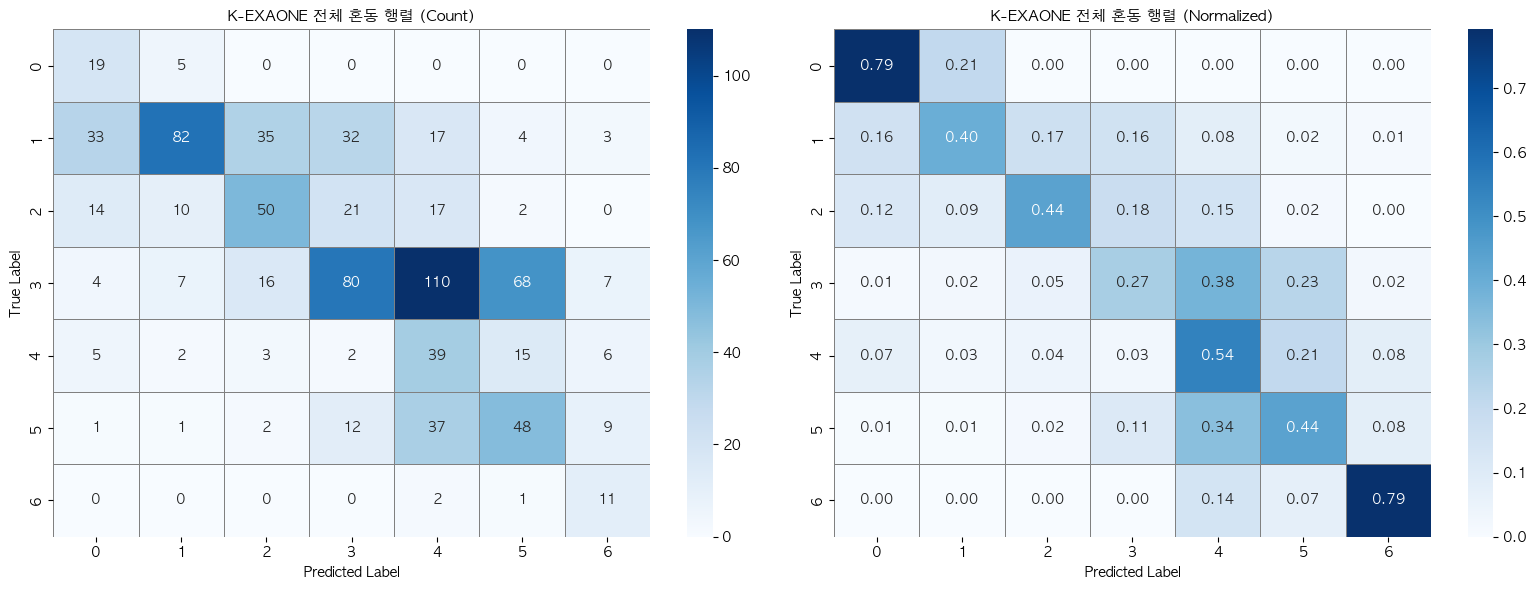


[가장 많이 혼동된 라벨 쌍 (Top 10)]


,True_Label,Pred_Label,Count,Error_Rate
0,3,4,110,0.3767
1,3,5,68,0.2329
2,5,4,37,0.3364
3,1,2,35,0.1699
4,1,0,33,0.1602
5,1,3,32,0.1553
6,2,3,21,0.1842
7,2,4,17,0.1491
8,1,4,17,0.0825
9,3,2,16,0.0548


In [6]:
# ============================================================
# 4-1. 전체 혼동 행렬 (모든 프롬프트 종합)
# ============================================================
print('=' * 70)
print('4-1. 전체 혼동 행렬 (K-EXAONE, 모든 프롬프트 종합)')
print('=' * 70)
print(f'총 샘플 수: {len(valid_df):,}개')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
cm_overall = plot_confusion_matrix(
    valid_df['Y_True'], valid_df['Y_Pred'],
    title='K-EXAONE 전체 혼동 행렬 (Count)', ax=axes[0])

# Normalized
plot_confusion_matrix(
    valid_df['Y_True'], valid_df['Y_Pred'],
    title='K-EXAONE 전체 혼동 행렬', ax=axes[1], normalize=True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_overall.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 혼동 쌍
print('\n[가장 많이 혼동된 라벨 쌍 (Top 10)]')
top_conf = get_top_confusions(cm_overall, top_n=10)
display(top_conf.reset_index(drop=True))

In [ ]:
# ============================================================
# 4-2. 프롬프트별 혼동 행렬
# ============================================================
prompts = sorted(valid_df['Prompt'].unique())
n_prompts = len(prompts)

print(f'프롬프트 수: {n_prompts}개')

# Normalized 혼동 행렬
n_cols = min(n_prompts, 3)
n_rows = int(np.ceil(n_prompts / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(6 * n_cols, 5 * n_rows),
                         squeeze=False)

for idx, prompt in enumerate(prompts):
    r, c = divmod(idx, n_cols)
    subset = valid_df[valid_df['Prompt'] == prompt]
    
    if len(subset) > 0:
        plot_confusion_matrix(
            subset['Y_True'], subset['Y_Pred'],
            title=f'K-EXAONE\n{prompt}',
            ax=axes[r, c], normalize=True)
    else:
        axes[r, c].text(0.5, 0.5, '데이터 없음',
                        ha='center', va='center', fontsize=14)
        axes[r, c].set_title(f'{prompt}')

# 남는 subplot 숨기기
for idx in range(n_prompts, n_rows * n_cols):
    r, c = divmod(idx, n_cols)
    axes[r, c].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_by_prompt.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 4-3. 프롬프트별 Top 5 혼동 쌍
# ============================================================
print('=' * 70)
print('4-3. 프롬프트별 Top 5 혼동 쌍')
print('=' * 70)

all_top_confusions = []

for prompt in prompts:
    subset = valid_df[valid_df['Prompt'] == prompt]
    if len(subset) == 0:
        continue

    cm = confusion_matrix(subset['Y_True'], subset['Y_Pred'], labels=LABELS)
    top = get_top_confusions(cm, top_n=5)
    top['Prompt'] = prompt
    all_top_confusions.append(top)

if all_top_confusions:
    top_conf_all = pd.concat(all_top_confusions, ignore_index=True)
    top_conf_all = top_conf_all[['Prompt', 'True_Label', 'Pred_Label', 'Count', 'Error_Rate']]

    for prompt in prompts:
        print(f'\n{"─" * 60}')
        print(f'  {prompt}')
        print(f'{"─" * 60}')
        prompt_data = top_conf_all[top_conf_all['Prompt'] == prompt]
        display(prompt_data.reset_index(drop=True))

---
## 5. 라벨별 정확도 분석

각 레이블에 대해 K-EXAONE이 올바르게 분류한 비율을 분석합니다.
- **히트맵**: 프롬프트×레이블 조합의 정확도를 색상으로 표시
- **Classification Report**: 레이블별 Precision, Recall, F1 상세 정보
- 소수 클래스(레이블 0, 6)에서 특히 낮은 정확도가 예상됨

In [ ]:
# ============================================================
# 5-1. 라벨별 정확도 히트맵
# ============================================================
print('=' * 70)
print('5-1. 라벨별 정확도')
print('=' * 70)

label_acc_records = []
for prompt in prompts:
    subset = valid_df[valid_df['Prompt'] == prompt]
    if len(subset) == 0:
        continue
    for label in LABELS:
        label_data = subset[subset['Y_True'] == label]
        if len(label_data) == 0:
            continue
        acc = (label_data['Y_Pred'] == label).mean()
        label_acc_records.append({
            'Prompt': prompt, 'Label': label,
            'N': len(label_data), 'Accuracy': round(acc, 4)
        })

label_acc_df = pd.DataFrame(label_acc_records)

# 히트맵
pivot = label_acc_df.pivot(index='Prompt', columns='Label', values='Accuracy')

fig, ax = plt.subplots(figsize=(10, max(3, len(prompts) * 0.8 + 1)))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            ax=ax, linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Per-Label Accuracy'})
ax.set_title('K-EXAONE 프롬프트별 라벨 정확도', fontsize=13, fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_label_accuracy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 라벨별 평균 정확도
print('\n[라벨별 평균 정확도 (전 프롬프트 평균)]')
label_mean = label_acc_df.groupby('Label')['Accuracy'].agg(['mean', 'std']).round(4)
label_mean.columns = ['Acc_Mean', 'Acc_Std']
display(label_mean)

In [ ]:
# ============================================================
# 5-2. Classification Report (프롬프트별)
# ============================================================
print('=' * 70)
print('5-2. Classification Report (프롬프트별)')
print('=' * 70)

for prompt in prompts:
    subset = valid_df[valid_df['Prompt'] == prompt]
    if len(subset) < 2:
        continue
    
    print(f'\n{"─" * 60}')
    print(f'  {prompt} (N={len(subset)})')
    print(f'{"─" * 60}')
    print(classification_report(
        subset['Y_True'], subset['Y_Pred'],
        labels=LABELS, zero_division=0
    ))

---
## 6. GPT-4o 결과와 비교

K-EXAONE과 GPT-4o의 성능을 동일 프롬프트에서 직접 비교합니다.

### 비교 의의
- **동일 프롬프트, 동일 데이터**에서 모델만 다르게 하여 순수 모델 성능 비교
- 한국어 특화 모델(K-EXAONE) vs 범용 모델(GPT-4o)의 성능 차이 확인

### 결과 해석
- GPT-4o가 모든 지표에서 K-EXAONE보다 크게 우수
- 한국어 특화가 반드시 한국어 과제 성능 향상을 보장하지 않음
- 가능한 원인: 모델 크기, 학습 데이터 품질, instruction following 능력의 차이

In [ ]:
# GPT-4o 결과 로드 (final_experiment의 detailed_predictions)
gpt4o_df = None

summary_dir = FINAL_DIR / 'summary'
detailed_files = sorted(summary_dir.glob('detailed_predictions_*.csv')) if summary_dir.exists() else []

if detailed_files:
    latest = detailed_files[-1]
    gpt4o_raw = pd.read_csv(latest)
    
    # GPT-4o + Seed 42 + Run 1만 필터
    gpt4o_df = gpt4o_raw[
        (gpt4o_raw['Model'] == 'GPT-4o') &
        (gpt4o_raw['Test_Seed'] == 42) &
        (gpt4o_raw['Run'] == 1) &
        (gpt4o_raw['Y_Pred'] != 'NA')
    ].copy()
    gpt4o_df['Y_Pred'] = gpt4o_df['Y_Pred'].astype(int)
    
    print(f'GPT-4o 결과 로드: {latest.name}')
    print(f'  - GPT-4o + Seed42 + Run1: {len(gpt4o_df)}개')
    print(f'  - 프롬프트: {gpt4o_df["Prompt"].unique().tolist()}')
else:
    print('GPT-4o 결과 파일 없음 (비교 건너뜀)')

In [ ]:
# GPT-4o vs K-EXAONE 성능 비교
if gpt4o_df is not None and len(gpt4o_df) > 0:
    print('=' * 70)
    print('GPT-4o vs K-EXAONE 성능 비교 (Seed 42, Run 1)')
    print('=' * 70)
    
    compare_records = []
    
    # GPT-4o 성능
    for prompt in sorted(gpt4o_df['Prompt'].unique()):
        subset = gpt4o_df[gpt4o_df['Prompt'] == prompt]
        y_true = subset['Y_True'].tolist()
        y_pred = subset['Y_Pred'].tolist()
        compare_records.append({
            'Model': 'GPT-4o',
            'Prompt': prompt,
            'N': len(subset),
            'Accuracy': round(accuracy_score(y_true, y_pred), 4),
            'F1_Macro': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
            'Kappa': round(cohen_kappa_score(y_true, y_pred), 4)
        })
    
    # K-EXAONE 성능 (이미 계산된 perf_df 활용)
    for _, row in perf_df.iterrows():
        compare_records.append({
            'Model': 'K-EXAONE-236B',
            'Prompt': row['Prompt'],
            'N': row['N_Valid'],
            'Accuracy': row['Accuracy'],
            'F1_Macro': row['F1_Macro'],
            'Kappa': row['Kappa']
        })
    
    compare_df = pd.DataFrame(compare_records).sort_values(['Prompt', 'Model'])
    display(compare_df)
    
    # 비교 차트
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    metrics = ['Accuracy', 'F1_Macro', 'Kappa']
    titles = ['Accuracy', 'F1 Macro', "Cohen's Kappa"]
    
    for ax, metric, title in zip(axes, metrics, titles):
        pivot = compare_df.pivot(index='Prompt', columns='Model', values=metric)
        pivot.plot(kind='barh', ax=ax, alpha=0.8)
        ax.set_title(title, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'gpt4o_vs_kexaone.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('GPT-4o 결과 없음 → 비교 건너뜀')

---
## 7. 결과 저장

분석 결과를 Excel 파일로 저장합니다.
- `성능요약` 시트: 프롬프트별 Accuracy, F1, Kappa
- `라벨별정확도` 시트: 프롬프트×레이블별 정확도
- `Top혼동쌍` 시트: 가장 많이 혼동된 레이블 쌍
- `GPT4o비교` 시트: GPT-4o와의 성능 비교 (있는 경우)

In [ ]:
# 분석 결과 Excel 저장
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
analysis_path = OUTPUT_DIR / f'kexaone_analysis_{timestamp}.xlsx'

with pd.ExcelWriter(analysis_path, engine='openpyxl') as writer:
    # 시트 1: 성능 요약
    perf_df.to_excel(writer, sheet_name='성능요약', index=False)
    
    # 시트 2: 라벨별 정확도
    label_acc_df.to_excel(writer, sheet_name='라벨별정확도', index=False)
    
    # 시트 3: Top 혼동 쌍
    if 'top_conf_all' in globals():
        top_conf_all.to_excel(writer, sheet_name='Top혼동쌍', index=False)
    
    # 시트 4: GPT-4o 비교 (있는 경우)
    if 'compare_df' in globals():
        compare_df.to_excel(writer, sheet_name='GPT4o비교', index=False)

print(f'분석 결과 저장: {analysis_path}')
print(f'  시트: 성능요약, 라벨별정확도, Top혼동쌍' + 
      (', GPT4o비교' if 'compare_df' in globals() else ''))

In [ ]:
# 종합 요약
print('\n' + '=' * 70)
print('K-EXAONE 분석 완료')
print('=' * 70)

if len(perf_df) > 0:
    best = perf_df.iloc[0]
    print(f'\n[최고 성능 프롬프트]')
    print(f'  Prompt:   {best["Prompt"]}')
    print(f'  Accuracy: {best["Accuracy"]:.4f}')
    print(f'  F1 Macro: {best["F1_Macro"]:.4f}')
    print(f'  Kappa:    {best["Kappa"]:.4f}')

print(f'\n완료 시간: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')